# Act 07 — Detección de regímenes y optimización por régimen (NVDA)

Microestructura y Sistemas de Trading, ITESO. Este notebook solo importa, ejecuta y presenta:
la lógica vive en `src/` (`regimes.py`, `regime_analysis.py`, `optimization.py`, `plots.py`).

**Datos:** `data/NVDA_daily.csv` recortado al fin de test (`SPLITS["test"][1]` = 2025-09-14).
Todo lo que se ajusta (scaler, umbral de reglas, K-means, HMM, θ) usa **solo train**; test solo se
evalúa. El periodo de validation **no se carga** en este notebook: queda intacto para la evaluación final.

| Periodo | Fechas | Uso |
|---|---|---|
| Train | 2021-09-15 a 2024-09-14 | ajuste de todo |
| Test | 2024-09-15 a 2025-09-14 | solo evaluación |
| Validation | 2025-09-15 en adelante | no se carga |

In [1]:
import re
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.analysis import win_rate_standard_error
from src.optimization import (MIN_TRADES, MIN_TRADES_REGIME, N_STARTUP_TRIALS, N_TRIALS, PARAM_SPACE,
                              THETA0, comparison_table as strategy_comparison, convergence_curve,
                              optimize_all, param_importances, strategy_runs, theta_table)
from src.plots import (plot_convergence, plot_elbow, plot_equity_curves, plot_feature_distributions,
                       plot_param_importances, plot_regime_timeline)
from src.regime_analysis import (METHODS, comparison_table, hmm_diagnostics, method_scorecard,
                                 regime_centroids, regime_return_profile, viterbi_lookahead_check)
from src.regimes import (HMM_SEEDS, MIN_DURATION, REGIME_NAMES, SEED, fit_regime_models,
                         hmm_expected_durations, hmm_seed_scan, kmeans_elbow, regime_features,
                         regime_labels)
from src.splits import SPLITS, get_split

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

TEST_END = SPLITS["test"][1]
TRAIN, TEST = SPLITS["train"], SPLITS["test"]
split_date = pd.Timestamp(TEST[0])

df = pd.read_csv("data/NVDA_daily.csv", index_col="Date", parse_dates=True).loc[:TEST_END]
assert df.index.max() <= pd.Timestamp(TEST_END)  # validation no se carga

features = regime_features(df)
models = fit_regime_models(df)      # scaler, umbral, K-means y HMM ajustados SOLO en train
labels = regime_labels(df, models)  # rules, kmeans, hmm (filtradas) y hmm_viterbi
features_train, features_test = get_split(features, "train"), get_split(features, "test")
labels_train, labels_test = get_split(labels, "train"), get_split(labels, "test")
print(f"Barras: {len(df)} ({df.index[0].date()} a {df.index[-1].date()}); "
      f"primera barra con features: {features.dropna().index[0].date()}")

Barras: 1003 (2021-09-15 a 2025-09-12); primera barra con features: 2021-12-14


## 1. Features de régimen (`regime_features`)

Tres features con una ventana móvil de **63 barras** (~un trimestre de sesiones), recalculadas
**cada día**. Son causales: el valor en t solo usa datos ≤ t.

| Feature | Fórmula (ventana de 63) | Qué mide y por qué se eligió |
|---|---|---|
| `volatility` | σ(r) · √252, con r_t = ln(C_t / C_{t−1}) | Nivel de volatilidad anualizada. Es lo que más separa calma de estrés y cambia el tamaño de los movimientos y el riesgo por trade. |
| `trend_r2` | R² de la regresión ln(C) = a + b·x, x = 0..62 (= corr(x, ln C)²) | Fuerza de la tendencia sin importar la dirección: ≈ 1 = el precio avanza en línea recta; ≈ 0 = lateral o ruidoso. En log-precio, un crecimiento porcentual constante es lineal. |
| `autocorr_1` | corr(r_{k−1}, r_k) sobre los 62 pares de la ventana | Reversión a la media (< 0: a una subida le sigue una bajada) vs persistencia (> 0). |

Estadísticos descriptivos por periodo (sin las 63 barras de warm-up):

In [2]:
pd.concat({"train": features_train.describe(), "test": features_test.describe()}, axis=1)

train                           test                    
      volatility trend_r2 autocorr_1 volatility trend_r2 autocorr_1
count   691.0000 692.0000   691.0000   249.0000 249.0000   249.0000
mean      0.5465   0.5134    -0.0222     0.5275   0.4923    -0.0981
std       0.1051   0.3096     0.0959     0.1529   0.3056     0.1135
min       0.2979   0.0001    -0.2758     0.2559   0.0000    -0.3008
25%       0.4840   0.2295    -0.0745     0.3897   0.2016    -0.2026
50%       0.5694   0.5697    -0.0152     0.5796   0.5119    -0.0925
75%       0.6166   0.7748     0.0310     0.6509   0.7395    -0.0296
max       0.7345   0.9738     0.2304     0.7971   0.9685     0.2011

**Prueba de truncamiento** (`tests/test_regimes.py::test_regime_feature_is_causal`): para cada columna y
25 barras t (cada 40 desde la 60, más la última), el valor en t con la serie completa es igual al
calculado con `df.iloc[:t+1]` (tolerancia 1e-9). Datos solo hasta fin de test.

In [3]:
run = subprocess.run([sys.executable, "-m", "pytest", "tests/test_regimes.py", "-k", "feature_is_causal",
                      "-v", "--color=no", "-p", "no:warnings"], capture_output=True, text=True)
results = pd.DataFrame(re.findall(r"test_regime_feature_is_causal\[(\w+)-(\d+)\] (PASSED|FAILED)", run.stdout),
                       columns=["columna", "t", "resultado"])
display(pd.crosstab(results["columna"], results["resultado"]))
print(run.stdout.strip().splitlines()[-1])

resultado,PASSED
columna,
autocorr_1,25
trend_r2,25
volatility,25


====================== 75 passed, 89 deselected in 1.41s =======================


## 2. Ajuste en train de los tres clasificadores

Los tres etiquetan cada barra por **nombre** ("crisis", "trend", "mean_reversion"), nunca por ID.
Las features se estandarizan con media y desviación **de train** (escalar con todo el dataset sería
look-ahead).

### 2.1 Reglas

1. **crisis** si volatility_t > p90(volatility en train);
2. **trend** si no es crisis y trend_r2_t > 0.5;
3. **mean_reversion** en cualquier otro caso.

In [4]:
print(f"Umbral de crisis = p90 de la volatilidad anualizada en train = {models.vol_threshold:.3f}")

Umbral de crisis = p90 de la volatilidad anualizada en train = 0.672


### 2.2 K-means

`KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)` sobre las features escaladas de train.
Los clusters se nombran por sus centroides en unidades originales: mayor volatilidad = crisis; de los
otros dos, mayor trend_r2 = trend; el restante = mean_reversion.

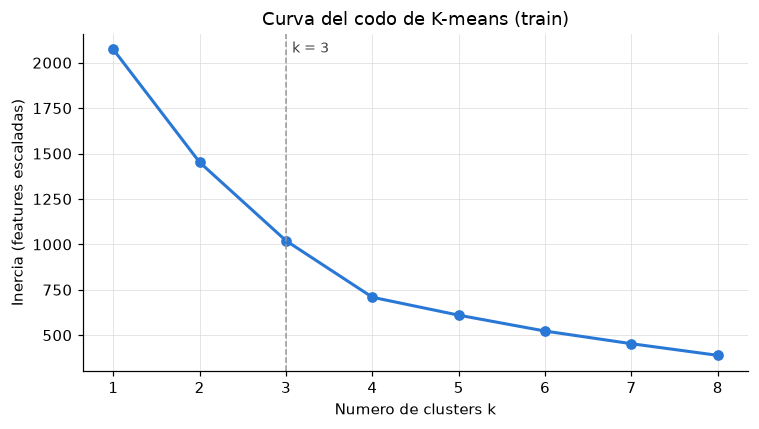

Caída de inercia al pasar a k: {2: 621, 3: 432, 4: 311, 5: 99, 6: 87, 7: 70, 8: 64}


In [5]:
elbow = kmeans_elbow(features_train, models.scaler)
fig, ax = plt.subplots(figsize=(7, 4))
plot_elbow(ax, elbow)
plt.tight_layout()
plt.show()
drops = (-elbow.diff()).dropna()
print("Caída de inercia al pasar a k:", {int(k): round(v) for k, v in drops.items()})

**¿Por qué k = 3 si el codo no está en 3?** La caída de inercia de 3 → 4 todavía es grande y se aplana
hasta 4 → 5 (cifras de arriba): por inercia, el codo estaría en k = 4. k se **fija a 3 por diseño**: la actividad
pide tres regímenes interpretables (estrés, tendencia, reversión/calma) que se puedan comparar uno a uno
con las reglas y el HMM y nombrar con la misma regla. Más clusters partirían regímenes en sub-estados
sin nombre económico y con menos barras para optimizar θ por régimen.

### 2.3 HMM gaussiano

`GaussianHMM(n_components=3, n_iter=200)` sobre las features escaladas de train. EM converge a óptimos
locales que dependen de la semilla. Con una sola semilla (42) el modelo quedaba con estados que duran
~1 barra (a_jj ≈ 0): eso es ruido, no un régimen. Por eso `fit_hmm` usa una **cascada decidida solo con
criterios de train** (log-likelihood y duración, nunca rendimientos):

1. `covariance_type="full"`, 10 semillas (0..9), se queda el de mayor log-likelihood en train;
   si todas las duraciones esperadas son ≥ 5 barras, se usa ese.
2. Si no, `"diag"` con el mismo criterio.
3. Si no, `"diag"` + prior Dirichlet en la diagonal de A (supuesto a priori: los regímenes persisten).

In [6]:
scan = hmm_seed_scan(features_train, models.scaler, seeds=[SEED, *HMM_SEEDS])
display(scan)
best_seed = scan.loc[list(HMM_SEEDS), "log_likelihood"].idxmax()
print(f"Semilla 42 sola: duración mínima = {scan.loc[SEED, 'min_duration']:.2f} barras.")
print(f"Opción elegida: '{models.hmm_choice}', semilla {models.hmm.random_state} "
      f"(log-likelihood {scan.loc[best_seed, 'log_likelihood']:.1f}); "
      f"todas las duraciones ≥ {MIN_DURATION} barras → no hizo falta 'diag' ni el prior.")

,log_likelihood,a_11,a_22,a_33,min_duration
seed,,,,,
42,"-2,375.9504",0.0014,0.0115,0.9757,1.0014
0,"-2,867.6330",0.2191,0.0001,0.0009,1.0001
1,"-2,497.2294",0.9833,0.0005,0.0957,1.0005
2,"-1,872.1297",0.9719,0.9732,0.9859,35.5654
3,"-1,864.2021",0.9859,0.9802,0.9713,34.8588
4,"-2,078.9580",0.9770,0.9547,0.9810,22.0738
5,"-1,805.4414",0.9819,0.9701,0.9919,33.4864
6,"-1,862.6653",0.9795,0.9673,0.9804,30.5489
7,"-1,862.6645",0.9673,0.9804,0.9795,30.5510


Semilla 42 sola: duración mínima = 1.00 barras.
Opción elegida: 'full', semilla 5 (log-likelihood -1805.4); todas las duraciones ≥ 5 barras → no hizo falta 'diag' ni el prior.


In [7]:
names = [models.hmm_names[j] for j in range(len(models.hmm_names))]
transmat = pd.DataFrame(models.hmm.transmat_, index=names, columns=names)
transmat.index.name, transmat.columns.name = "desde", "hacia"
display(transmat.loc[REGIME_NAMES, REGIME_NAMES])
hmm_expected_durations(models.hmm, models.hmm_names).loc[REGIME_NAMES].to_frame("duración esperada 1/(1−a_jj) (barras)")

hacia,crisis,trend,mean_reversion
desde,,,
crisis,0.9819,0.0151,0.0030
trend,0.0299,0.9701,0.0000
mean_reversion,0.0000,0.0081,0.9919


,duración esperada 1/(1−a_jj) (barras)
crisis,55.2980
trend,33.4864
mean_reversion,122.9868


**Etiqueta filtrada vs Viterbi.** La etiqueta que se usa es la **filtrada**: argmax de
P(s_t | x_1..x_t) con el algoritmo forward explícito (`hmm_forward`), que solo usa datos ≤ t.
Viterbi (`model.predict`) elige la secuencia más probable dada **toda** la serie y la reconstruye con
backtracking desde la última barra: la etiqueta en t depende de x_{t+1..T} (look-ahead). Se muestra solo
para comparar.

## 3. Comparación de los tres clasificadores (etiquetas filtradas)

- **silhouette**: separación de los regímenes en las features escaladas con el scaler de train (−1 a 1).
- **duración media**: promedio de las rachas consecutivas, en barras (se cortan en el borde del periodo).
- **transiciones/mes**: cambios de etiqueta / (barras / 21).
- **participación**: % de barras en cada régimen.

In [8]:
table = comparison_table(labels, features, models.scaler)
table.T

method                         rules          kmeans              hmm        
period                         train    test   train    test    train    test
silhouette                    0.2763  0.1392  0.3479  0.3975   0.2993  0.3697
mean_duration_crisis         34.5000 10.0000 23.7000 42.3333  47.8571 50.3333
mean_duration_trend          49.4286 16.8333 33.1111 12.0000  33.4286 10.0000
mean_duration_mean_reversion 30.6667 18.0000 26.0000 10.0000 122.0000 19.3333
mean_duration_all            38.3889 15.5625 27.6400 17.7857  46.0667 24.9000
transitions_per_month         0.5166  1.2651  0.7294  1.0964   0.4255  0.7590
share_crisis                  9.9855 16.0643 34.2981 51.0040  48.4805 60.6426
share_trend                  50.0724 40.5622 43.1259 28.9157  33.8640 16.0643
share_mean_reversion         39.9421 43.3735 22.5760 20.0803  17.6556 23.2932

In [9]:
hmm_durations, hmm_agreement = hmm_diagnostics(labels, models.hmm, models.hmm_names)
display(hmm_durations.rename(columns={"expected": "esperada 1/(1−a_jj)",
                                      "observed_train": "observada train", "observed_test": "observada test"}))
hmm_agreement.to_frame("% de barras con filtrado == Viterbi")

,esperada 1/(1−a_jj),observada train,observada test
crisis,55.2980,47.8571,50.3333
trend,33.4864,33.4286,10.0000
mean_reversion,122.9868,122.0000,19.3333


,% de barras con filtrado == Viterbi
train,96.3821
test,93.5743


## 4. Línea de tiempo: precio coloreado por régimen

Tres paneles con la etiqueta **filtrada** de cada método y un cuarto con HMM **Viterbi** para comparar.
La línea punteada marca el inicio de test.

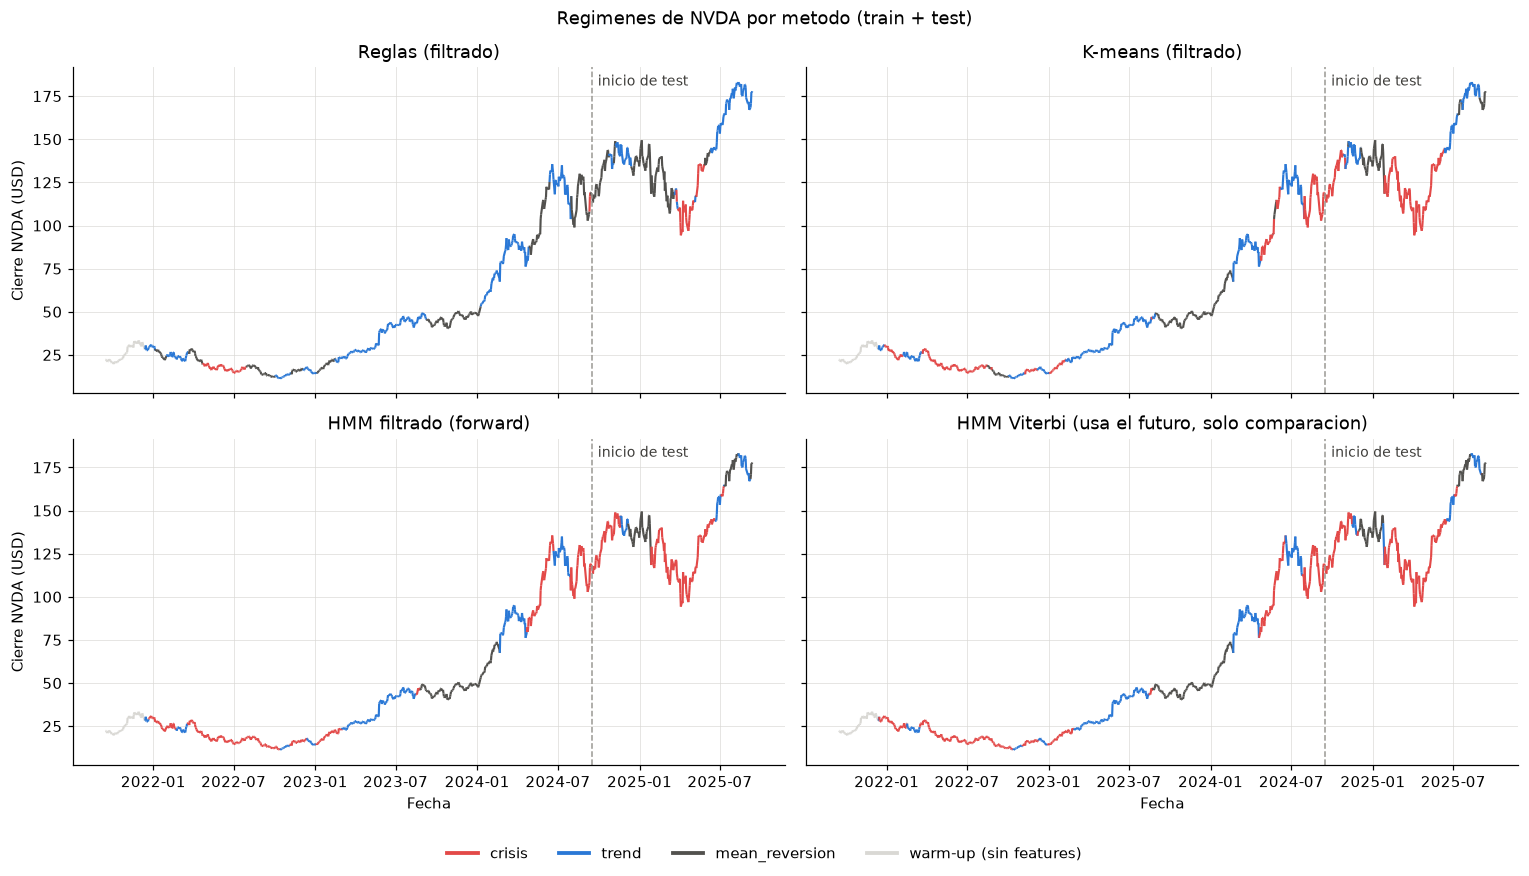

In [10]:
fig = plot_regime_timeline(df["Close"], labels, split_date)
plt.show()

**Canario de look-ahead.** Para una barra t de cada 5 (desde la primera con features) se recalculan las
etiquetas con `df.iloc[:t+1]` usando los modelos ya ajustados, y se comparan con las de la serie completa.
La filtrada no debe cambiar nunca; Viterbi sí cambia cuando llegan datos posteriores.

In [11]:
check = viterbi_lookahead_check(df, models, step=5)
canary = pd.DataFrame({
    "t revisadas": len(check),
    "t con etiqueta distinta al truncar": (~check).sum(),
}).rename(index={"hmm_same": "HMM filtrado", "hmm_viterbi_same": "HMM Viterbi"})
display(canary)
changed = check.index[~check["hmm_viterbi_same"]]
print("Primeras fechas donde Viterbi cambia:", [d.date().isoformat() for d in changed[:5]])

,t revisadas,t con etiqueta distinta al truncar
HMM filtrado,188,0
HMM Viterbi,188,13


Primeras fechas donde Viterbi cambia: ['2021-12-21', '2022-02-17', '2022-03-18', '2022-10-14', '2022-11-04']


## 5. Distribución de features por régimen y nombres

Boxplots de cada feature por régimen (una fila por método, train + test):

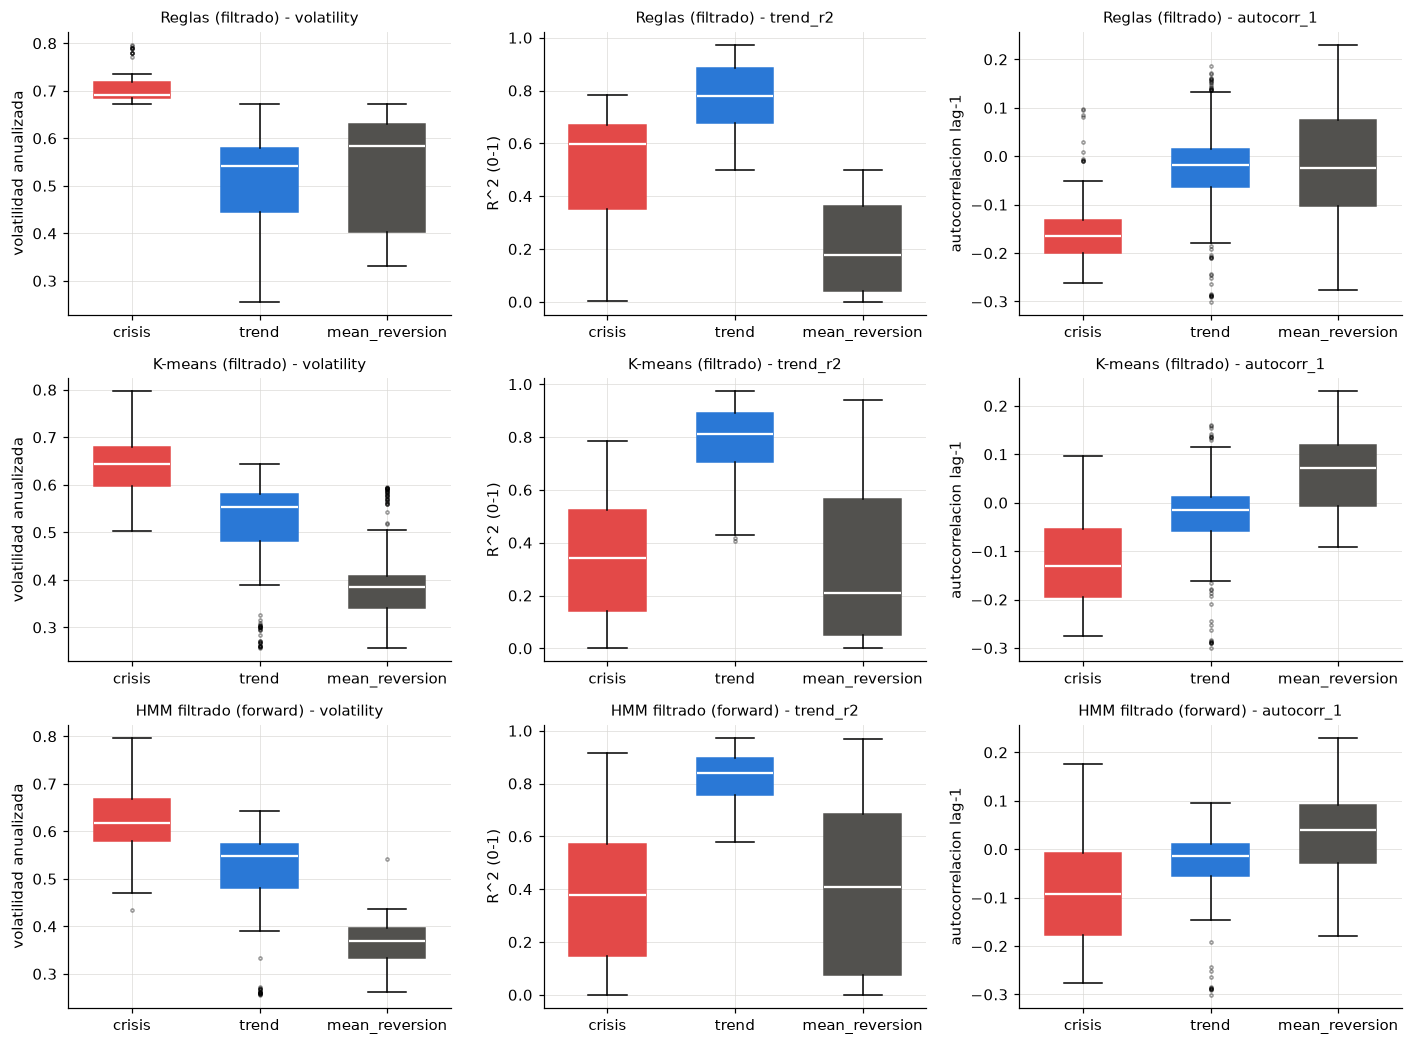

In [12]:
fig = plot_feature_distributions(features, labels)
plt.show()

In [13]:
centroids_train = regime_centroids(labels_train[METHODS], features_train)
centroids_test = regime_centroids(labels_test[METHODS], features_test)
pd.concat({"train": centroids_train, "test": centroids_test}, axis=1)

train                           test           \
                      volatility trend_r2 autocorr_1 volatility trend_r2   
method regime                                                              
rules  crisis             0.7008   0.5384    -0.1298     0.7137   0.4516   
       mean_reversion     0.5324   0.1923    -0.0079     0.5608   0.2362   
       trend              0.5270   0.7635    -0.0121     0.4180   0.7823   
kmeans crisis             0.6348   0.3314    -0.0909     0.6536   0.3423   
       mean_reversion     0.4119   0.2853     0.0623     0.3632   0.4137   
       trend              0.5467   0.7764    -0.0118     0.4190   0.8116   
hmm    crisis             0.6167   0.3594    -0.0496     0.6317   0.3880   
       mean_reversion     0.3660   0.3386     0.0421     0.3520   0.5173   
       trend              0.5401   0.8236    -0.0165     0.3882   0.8497   

                                  
                      autocorr_1  
method regime                     
rules  crisis            -0.1823  
       mean_reversion    -0.0897  
       trend             -0.0736  
kmeans crisis            -0.1662  
       mean_reversion     0.0536  
       trend             -0.0833  
hmm    crisis            -0.1496  
       mean_reversion     0.0376  
       trend             -0.1004

In [14]:
c = centroids_train.loc["hmm"]
display(Markdown(f'''
**Justificación de los nombres (honesta).** Los nombres salen de una regla fija sobre los centroides de
train: mayor volatilidad = "crisis"; de los otros dos, mayor trend_r2 = "trend"; el restante =
"mean_reversion". En el HMM eso significa:

- **"crisis" = régimen de alta volatilidad (estrés)**, no necesariamente una caída: volatilidad media
  {c.loc["crisis", "volatility"]:.2f} en train, contra {c.loc["trend", "volatility"]:.2f} en trend y
  {c.loc["mean_reversion", "volatility"]:.2f} en mean_reversion. Ocupa {table.loc[("hmm", "train"), "share_crisis"]:.0f}% de
  train, mucho más que el {table.loc[("rules", "train"), "share_crisis"]:.0f}% de las reglas: es el "estado volátil" de NVDA, no una cola extrema.
- **"trend"** = tendencia limpia: trend_r2 medio {c.loc["trend", "trend_r2"]:.2f}.
- **"mean_reversion" = régimen de calma**: es el de **menor volatilidad**
  ({c.loc["mean_reversion", "volatility"]:.2f}) y su autocorrelación lag-1 es ≈ 0 y **no negativa**
  ({c.loc["mean_reversion", "autocorr_1"]:+.3f}). Lleva ese nombre por descarte; no hay evidencia de
  reversión a la media en ese estado. La autocorrelación más negativa está en "crisis"
  ({c.loc["crisis", "autocorr_1"]:+.3f}).
'''))


**Justificación de los nombres (honesta).** Los nombres salen de una regla fija sobre los centroides de
train: mayor volatilidad = "crisis"; de los otros dos, mayor trend_r2 = "trend"; el restante =
"mean_reversion". En el HMM eso significa:

- **"crisis" = régimen de alta volatilidad (estrés)**, no necesariamente una caída: volatilidad media
  0.62 en train, contra 0.54 en trend y
  0.37 en mean_reversion. Ocupa 48% de
  train, mucho más que el 10% de las reglas: es el "estado volátil" de NVDA, no una cola extrema.
- **"trend"** = tendencia limpia: trend_r2 medio 0.82.
- **"mean_reversion" = régimen de calma**: es el de **menor volatilidad**
  (0.37) y su autocorrelación lag-1 es ≈ 0 y **no negativa**
  (+0.042). Lleva ese nombre por descarte; no hay evidencia de
  reversión a la media en ese estado. La autocorrelación más negativa está en "crisis"
  (-0.050).


**Perfil de rendimiento por régimen (descriptivo).** A la etiqueta de t se le asocia el rendimiento del
día siguiente, Close_{t+1}/Close_t − 1 (lo que se gana después de conocer el régimen). Rendimiento medio
× 252 y volatilidad × √252. **No se usó para elegir método ni para ajustar nada**: solo muestra si los
regímenes son económicamente distintos. Con 40–60 barras en algunos grupos de test, las medias anualizadas
tienen mucho ruido.

In [15]:
regime_return_profile(df, labels).unstack("period")

n_bars       ann_return        ann_volatility       
period                  test train       test  train           test  train
method regime                                                             
hmm    crisis            151   335     0.7602 0.3252         0.5213 0.6351
       mean_reversion     57   122     0.4572 1.1530         0.5461 0.4154
       trend              40   234    -0.0994 0.9305         0.3108 0.5390
kmeans crisis            127   237     0.7552 0.3158         0.5493 0.5893
       mean_reversion     49   156     0.0728 0.9732         0.5814 0.5700
       trend              72   298     0.5194 0.8076         0.3146 0.5539
rules  crisis             40    69     1.2437 0.0104         0.6999 0.6692
       mean_reversion    108   276     0.7602 0.5134         0.5488 0.5355
       trend             100   346     0.0502 0.9390         0.3148 0.5750

## 6. Elección del método

Criterios fijados **antes** de mirar los resultados de la optimización y sin usar rendimientos:

| Criterio | Por qué importa | Medida |
|---|---|---|
| Causalidad | La etiqueta debe poder conocerse al cierre de t | Las tres etiquetas filtradas pasan truncamiento; Viterbi no se usa |
| Persistencia | Cada cambio de régimen cambia θ y genera rotación y costos; un régimen de 2 barras no se puede operar | Transiciones/mes y duración media en test |
| Estabilidad train → test | Lo aprendido en train debe seguir valiendo fuera de muestra | Cambio medio de participación (pp) y de transiciones/mes |
| Separación | Regímenes compactos y distintos en el espacio de features | Silhouette train y test |
| Consistencia interna | La regla de nombres debe seguir valiendo con los centroides de test | `names_consistent_*` |
| Explicabilidad | Poder explicar por qué una barra está en un régimen | Cualitativo |

In [16]:
scorecard = method_scorecard(table, centroids_train, centroids_test)
scorecard["explicabilidad"] = pd.Series({
    "rules": "alta: umbrales fijos y legibles",
    "kmeans": "media: distancia al centroide más cercano, sin memoria",
    "hmm": "media: estados con medias/covarianzas y matriz de transición; persistencia explícita",
})
scorecard.T

method,rules,kmeans,hmm
transitions_per_month_test,1.2651,1.0964,0.7590
mean_duration_test,15.5625,17.7857,24.9000
share_shift_pp,6.3401,11.1373,11.8665
transitions_change,0.7484,0.3670,0.3336
silhouette_train,0.2763,0.3479,0.2993
silhouette_test,0.1392,0.3975,0.3697
names_consistent_train,True,True,True
names_consistent_test,True,True,True
explicabilidad,alta: umbrales fijos y legibles,"media: distancia al centroide más cercano, sin...",media: estados con medias/covarianzas y matriz...


In [17]:
s = scorecard
display(Markdown(f'''
**Elección: HMM filtrado.**

- **Persistencia (criterio principal):** el HMM tiene la menor tasa de cambio en test
  ({s.loc["hmm", "transitions_per_month_test"]:.2f} transiciones/mes vs
  {s.loc["kmeans", "transitions_per_month_test"]:.2f} de K-means y {s.loc["rules", "transitions_per_month_test"]:.2f}
  de reglas) y las rachas más largas ({s.loc["hmm", "mean_duration_test"]:.1f} barras vs
  {s.loc["kmeans", "mean_duration_test"]:.1f} y {s.loc["rules", "mean_duration_test"]:.1f}). Es lo esperable: la matriz A
  le da memoria, mientras que K-means y las reglas clasifican cada barra por separado.
- **Estabilidad de la tasa de cambio:** sus transiciones/mes son las que menos suben de train a test
  ({s.loc["hmm", "transitions_change"]:+.2f} vs {s.loc["kmeans", "transitions_change"]:+.2f} y
  {s.loc["rules", "transitions_change"]:+.2f}). Además, la etiqueta filtrada coincide con Viterbi en
  {hmm_agreement["test"]:.1f}% de test: filtrar casi no pierde frente a usar el futuro.
- **Dónde no gana:** la participación por régimen cambia más de train a test en el HMM
  ({s.loc["hmm", "share_shift_pp"]:.1f} pp en promedio) que en las reglas ({s.loc["rules", "share_shift_pp"]:.1f} pp),
  y su silhouette ({s.loc["hmm", "silhouette_test"]:.3f} en test) es menor que el de K-means.
- **Segunda opción: K-means**, con el mejor silhouette en train y test
  ({s.loc["kmeans", "silhouette_train"]:.3f} / {s.loc["kmeans", "silhouette_test"]:.3f}), pero sin memoria:
  cambia de etiqueta más seguido y produce rachas más cortas.
- Las reglas son las más explicables, pero tienen la peor separación en test
  ({s.loc["rules", "silhouette_test"]:.3f}) y la mayor tasa de cambio.
- La regla de nombres es consistente en train y test en los tres métodos.
'''))


**Elección: HMM filtrado.**

- **Persistencia (criterio principal):** el HMM tiene la menor tasa de cambio en test
  (0.76 transiciones/mes vs
  1.10 de K-means y 1.27
  de reglas) y las rachas más largas (24.9 barras vs
  17.8 y 15.6). Es lo esperable: la matriz A
  le da memoria, mientras que K-means y las reglas clasifican cada barra por separado.
- **Estabilidad de la tasa de cambio:** sus transiciones/mes son las que menos suben de train a test
  (+0.33 vs +0.37 y
  +0.75). Además, la etiqueta filtrada coincide con Viterbi en
  93.6% de test: filtrar casi no pierde frente a usar el futuro.
- **Dónde no gana:** la participación por régimen cambia más de train a test en el HMM
  (11.9 pp en promedio) que en las reglas (6.3 pp),
  y su silhouette (0.370 en test) es menor que el de K-means.
- **Segunda opción: K-means**, con el mejor silhouette en train y test
  (0.348 / 0.398), pero sin memoria:
  cambia de etiqueta más seguido y produce rachas más cortas.
- Las reglas son las más explicables, pero tienen la peor separación en test
  (0.139) y la mayor tasa de cambio.
- La regla de nombres es consistente en train y test en los tres métodos.


## 7. Optimización de θ (global y por régimen HMM)

**θ** = (roc_window, cmf_window, adx_threshold, sl_mult, rr, max_holding), con tp_mult = sl_mult · rr.
ATR(14), ρ = 1% y costos quedan fijos: no son parámetros de la señal. Espacio de búsqueda y θ0 (SPEC, Act 06):

In [18]:
pd.DataFrame({name: {"tipo": "entero" if kind == "int" else "real", "mínimo": low, "máximo": high,
                     "θ0": THETA0[name]}
              for name, (kind, low, high) in PARAM_SPACE.items()}).T

,tipo,mínimo,máximo,θ0
roc_window,entero,5,30,10
cmf_window,entero,10,40,20
adx_threshold,real,15.0000,35.0000,25.0000
sl_mult,real,1.0000,3.0000,2.0000
rr,real,1.0000,3.0000,1.5000
max_holding,entero,5,20,10


- **Objetivo:** J = Calmar (CAGR / |max drawdown|) del backtest en **train**. Si el backtest tiene menos de
  `MIN_TRADES` trades cerrados (20 para θ* único, 10 por régimen), J = −∞ y la configuración se descarta,
  para no premiar θ con 2 o 3 trades afortunados.
- **Búsqueda:** Optuna, `TPESampler(n_startup_trials=150, seed=42)`, 500 trials. Los primeros 150 son
  aleatorios (random search: exploran todo el espacio sin suponer nada). Después TPE separa los trials en
  "buenos" y "malos", estima p(θ | bueno) y p(θ | malo) y propone el θ que maximiza su cociente
  (búsqueda bayesiana).
- **θ\* único:** maximiza J(backtest(train, θ)).
- **θ\*_j por régimen:** maximiza J del backtest en train donde solo se permiten **entradas** cuando la
  etiqueta HMM filtrada de la barra de señal (t−1) es j. **Regla a priori:** si el mejor J_j ≤ 0 o no
  alcanza el mínimo de trades, en ese régimen no se opera.
- **Estrategia combinada (θ\*_régimen):** en cada barra la señal sale de θ\*_{ŝ_t} con la etiqueta
  filtrada ŝ_t (conocida al cierre de t, ejecución al open de t+1); SL/TP/holding se fijan con el θ del
  régimen al entrar. Su causalidad se prueba con truncamiento en `tests/test_optimization.py`.

In [19]:
start = time.time()
opt = optimize_all(df, models)   # 4 estudios x 500 trials, SOLO con train
print(f"Optimización: {time.time() - start:.0f} s")
thetas = theta_table(df, models, opt)
thetas

Optimización: 9 s


,roc_window,cmf_window,adx_threshold,sl_mult,rr,max_holding,tp_mult,J_train,trades_train,operates
θ0,10,20,25.0000,2.0000,1.5000,10,3.0000,1.6830,62,True
θ*,16,18,34.5345,2.3387,2.6883,17,6.2872,4.9504,20,True
θ*_crisis,12,16,26.4941,1.9468,1.0403,9,2.0253,2.4214,24,True
θ*_trend,18,23,34.9693,2.5038,1.0654,5,2.6675,3.4256,24,True
θ*_mean_reversion,5,34,15.4217,2.9665,1.1389,7,3.3787,2.3982,17,True


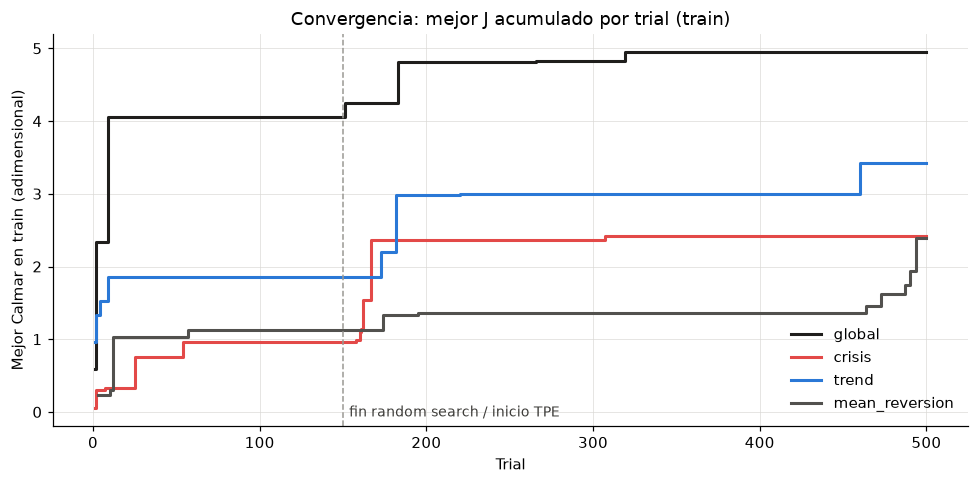

,mejor trial,trials con J = −∞
global,319,0
crisis,307,21
trend,460,0
mean_reversion,494,126


In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_convergence(ax, {name: convergence_curve(study) for name, study in opt.studies.items()},
                 n_startup=N_STARTUP_TRIALS)
plt.tight_layout()
plt.show()
pd.DataFrame({name: {"mejor trial": study.best_trial.number + 1,
                     "trials con J = −∞": int(np.isinf([t.value for t in study.trials]).sum())}
              for name, study in opt.studies.items()}).T

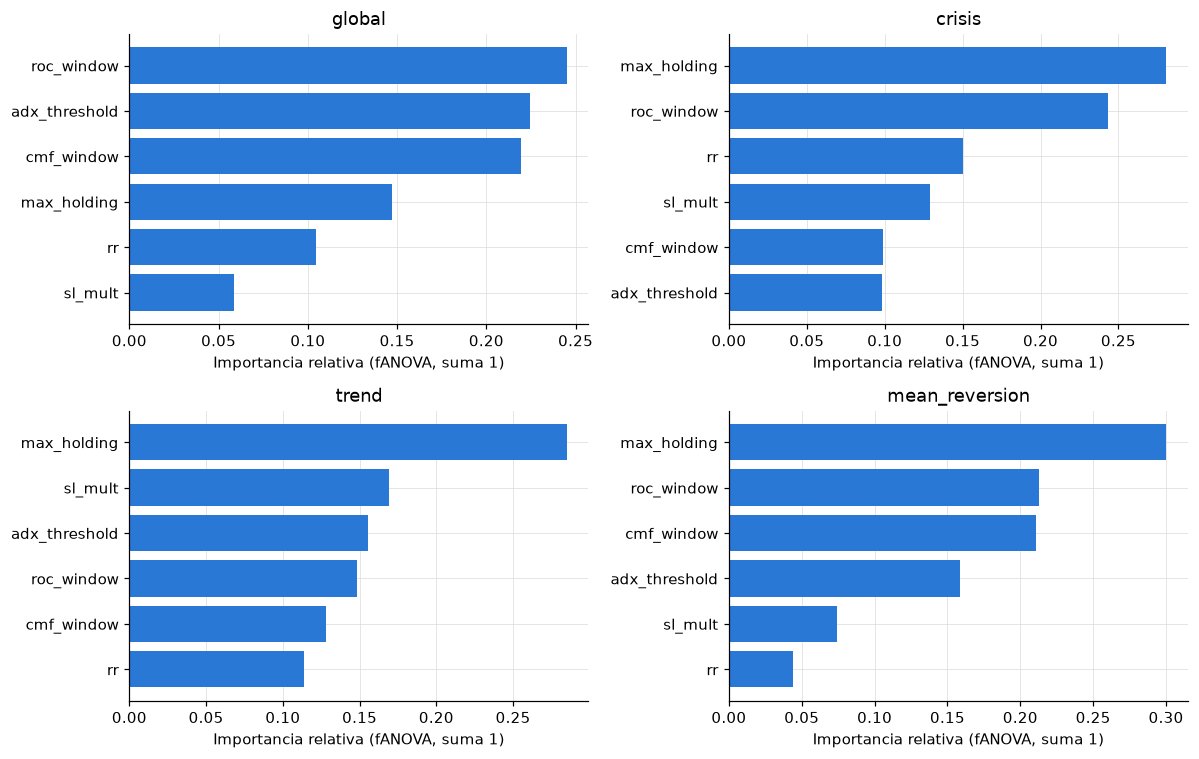

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, study) in zip(axes.flat, opt.studies.items()):
    plot_param_importances(ax, param_importances(study), name)
plt.tight_layout()
plt.show()

Curvas de equity sobre train + test continuos (una sola corrida por estrategia; las métricas de cada
periodo se calculan con `summarize`, que rebasa la equity al inicio del periodo, como en Act 06).

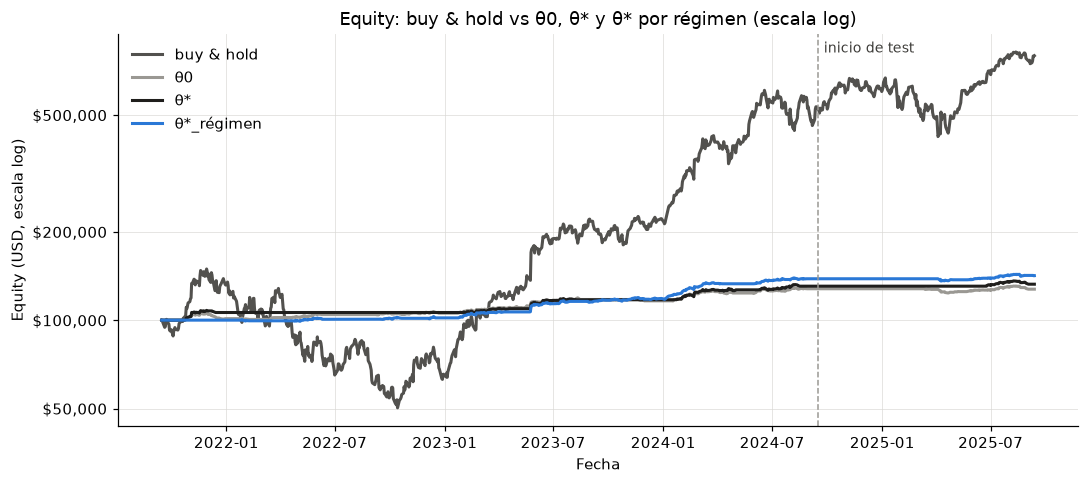

In [22]:
runs = strategy_runs(df, models, opt)
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_equity_curves(ax, {name: equity["equity"] for name, (equity, _, _) in runs.items()}, split_date)
plt.tight_layout()
plt.show()

In [23]:
results = strategy_comparison(df, models, opt)
results

,buy & hold train,buy & hold test,θ0 train,θ0 test,θ* train,θ* test,θ*_régimen train,θ*_régimen test
equity_final,"533,024.8874","152,267.4842","127,922.5287","99,678.1842","130,525.8485","101,567.1787","138,346.7251","102,443.6035"
total_return,4.3302,0.5227,0.2792,-0.0032,0.3053,0.0157,0.3835,0.0244
cagr,0.7507,0.5330,0.0859,-0.0033,0.0932,0.0159,0.1147,0.0248
sharpe,1.2680,1.1075,1.6670,-0.0875,1.7162,0.6354,2.3250,0.7675
sortino,2.0242,1.5979,3.1899,-0.1159,3.9290,0.9445,5.2066,1.0455
max_drawdown,-0.6635,-0.3689,-0.0510,-0.0328,-0.0188,-0.0254,-0.0166,-0.0177
calmar,1.1314,1.4451,1.6830,-0.0998,4.9504,0.6271,6.9275,1.4049
n_trades,0.0000,0.0000,62.0000,12.0000,20.0000,4.0000,63.0000,13.0000
trades_per_year,0.0000,0.0000,20.7490,12.1935,6.6932,4.0645,21.0837,13.2097
avg_pnl,NaN,NaN,450.3634,-34.3062,"1,526.2924",511.3933,608.6782,282.6552


`p_star`, `p_star_cost` y `k_mean` suponen un solo SL/TP y no aplican a la estrategia por régimen (NaN).

## 8. Conclusiones

In [24]:
r = results.loc
n_reg, p_reg = int(r["n_trades", "θ*_régimen test"]), r["win_rate", "θ*_régimen test"]
se_reg = win_rate_standard_error(p_reg, n_reg)
star, trend = opt.theta_star, opt.studies["trend"].best_params
adx_high = PARAM_SPACE["adx_threshold"][2]
display(Markdown(f'''
**¿Operar por régimen mejora?** Frente a las otras dos versiones de la misma estrategia, sí en test:
Calmar {r["calmar", "θ*_régimen test"]:.2f} vs {r["calmar", "θ* test"]:.2f} (θ\\*) y {r["calmar", "θ0 test"]:.2f} (θ0);
Sharpe {r["sharpe", "θ*_régimen test"]:.2f} vs {r["sharpe", "θ* test"]:.2f} y {r["sharpe", "θ0 test"]:.2f};
rendimiento {r["total_return", "θ*_régimen test"]:+.1%} vs {r["total_return", "θ* test"]:+.1%} y
{r["total_return", "θ0 test"]:+.1%}. **No le gana a buy & hold en rendimiento** ({r["total_return", "buy & hold test"]:+.1%}
en test): su Calmar es parecido ({r["calmar", "θ*_régimen test"]:.2f} vs {r["calmar", "buy & hold test"]:.2f}),
pero con un max drawdown mucho menor ({r["max_drawdown", "θ*_régimen test"]:.1%} vs {r["max_drawdown", "buy & hold test"]:.1%})
y exposición de {r["exposure", "θ*_régimen test"]:.0%} contra 100%.

**Señales de overfitting (hay que leer los resultados con cautela):**

- **Caída train → test:** el Calmar de θ\\* pasa de {r["calmar", "θ* train"]:.2f} a {r["calmar", "θ* test"]:.2f}
  y el de θ\\*_régimen de {r["calmar", "θ*_régimen train"]:.2f} a {r["calmar", "θ*_régimen test"]:.2f}.
- **θ\\* pegado a la restricción:** hace {thetas.loc["θ*", "trades_train"]} trades en train, justo el mínimo
  ({MIN_TRADES}); su win rate de {r["win_rate", "θ* train"]:.0%} y profit factor de {r["profit_factor", "θ* train"]:.1f}
  en train salen de pocos trades.
- **ADX en el borde del espacio:** el umbral de ADX de θ\\* es {star["adx_threshold"]:.1f} y el de θ\\*_trend
  {trend["adx_threshold"]:.1f}, contra un máximo de {adx_high:.0f}: el óptimo podría estar fuera del rango.
- **mean_reversion sin converger:** su mejor trial fue el {opt.studies["mean_reversion"].best_trial.number + 1}
  de {N_TRIALS}; más trials podrían mover su θ.
- **Pocos trades en test:** θ\\* hace {int(r["n_trades", "θ* test"])}, θ0 {int(r["n_trades", "θ0 test"])} y
  θ\\*_régimen {n_reg}; el win rate de θ\\*_régimen en test ({p_reg:.0%}, n = {n_reg}) tiene un error estándar
  de {se_reg * 100:.0f} pp.

**Por qué no se ajustó nada después de ver test.** El método de régimen se eligió con criterios fijados de
antemano (sin rendimientos), y θ\\*, θ\\*_j, MIN_TRADES, el espacio de búsqueda y la regla a priori se fijaron
antes de correr test. Cambiar cualquiera de ellos al ver estas cifras convertiría test en otro periodo de
ajuste y sus métricas dejarían de ser fuera de muestra. Precisión: los criterios de elección del método son
estructurales y no usan rendimientos, pero algunos se midieron también en test (silhouette, transiciones/mes y
duración de las rachas en la sección 6). Por eso test no está 100% intacto para la elección del método, y la
evaluación final y honesta es validation. Además, como se declaró en la auditoría de sesgos de Act 06, durante
el desarrollo de Act 05/06 se vieron resultados del periodo completo (incluida validation) en corridas de
prueba, sin ajustar nada con ellos.

**Validation no se usó para ajustar nada:** este notebook nunca carga datos posteriores a {TEST_END};
ningún parámetro, umbral ni método se eligió con validation. Su única exposición fue la declarada en Act 06
(corridas de prueba del periodo completo durante el desarrollo, sin ajustar nada). La evaluación final de la
estrategia por régimen, con todo congelado, se hará una sola vez en validation.
'''))


**¿Operar por régimen mejora?** Frente a las otras dos versiones de la misma estrategia, sí en test:
Calmar 1.40 vs 0.63 (θ\*) y -0.10 (θ0);
Sharpe 0.77 vs 0.64 y -0.09;
rendimiento +2.4% vs +1.6% y
-0.3%. **No le gana a buy & hold en rendimiento** (+52.3%
en test): su Calmar es parecido (1.40 vs 1.45),
pero con un max drawdown mucho menor (-1.8% vs -36.9%)
y exposición de 27% contra 100%.

**Señales de overfitting (hay que leer los resultados con cautela):**

- **Caída train → test:** el Calmar de θ\* pasa de 4.95 a 0.63
  y el de θ\*_régimen de 6.93 a 1.40.
- **θ\* pegado a la restricción:** hace 20 trades en train, justo el mínimo
  (20); su win rate de 80% y profit factor de 8.6
  en train salen de pocos trades.
- **ADX en el borde del espacio:** el umbral de ADX de θ\* es 34.5 y el de θ\*_trend
  35.0, contra un máximo de 35: el óptimo podría estar fuera del rango.
- **mean_reversion sin converger:** su mejor trial fue el 494
  de 500; más trials podrían mover su θ.
- **Pocos trades en test:** θ\* hace 4, θ0 12 y
  θ\*_régimen 13; el win rate de θ\*_régimen en test (77%, n = 13) tiene un error estándar
  de 12 pp.

**Por qué no se ajustó nada después de ver test.** El método de régimen se eligió con criterios fijados de
antemano (sin rendimientos), y θ\*, θ\*_j, MIN_TRADES, el espacio de búsqueda y la regla a priori se fijaron
antes de correr test. Cambiar cualquiera de ellos al ver estas cifras convertiría test en otro periodo de
ajuste y sus métricas dejarían de ser fuera de muestra. Precisión: los criterios de elección del método son
estructurales y no usan rendimientos, pero algunos se midieron también en test (silhouette, transiciones/mes y
duración de las rachas en la sección 6). Por eso test no está 100% intacto para la elección del método, y la
evaluación final y honesta es validation. Además, como se declaró en la auditoría de sesgos de Act 06, durante
el desarrollo de Act 05/06 se vieron resultados del periodo completo (incluida validation) en corridas de
prueba, sin ajustar nada con ellos.

**Validation no se usó para ajustar nada:** este notebook nunca carga datos posteriores a 2025-09-14;
ningún parámetro, umbral ni método se eligió con validation. Su única exposición fue la declarada en Act 06
(corridas de prueba del periodo completo durante el desarrollo, sin ajustar nada). La evaluación final de la
estrategia por régimen, con todo congelado, se hará una sola vez en validation.
